# Task 2: SED Modeling with QSOSED
# Author:Israt Sultana Eithu

## Objective

The goal of this exercise is to investigate how black hole mass ($M_{BH}$), spin ($a_*$), and accretion rate ($\dot{m}$) affect the spectral energy distribution (SED) of active galactic nuclei (AGN).

The QSOSED model (Kubota & Done 2018) was used to generate and compare SEDs for three different AGN configurations:

1. Super-Eddington Narrow-Line Seyfert 1 (NLS1)
2. Ark 120
3. NGC 5548

Following the tutorial instructions, the hot corona radius and warm corona radius were kept fixed.

## Part (a): Generate SEDs for Three AGN Configurations

The following AGN parameters were used.

| Source | MBH (M☉) | Spin | mdot | Distance (Mpc) |
|----------|------------|---------|---------|----------|
| Super-Eddington NLS1 | 2 × 10⁶ | 0.90 | 1.00 | 180 |
| Ark 120 | 1.5 × 10⁸ | 0.83 | 0.10 | 140 |
| NGC 5548 | 6.5 × 10⁷ | 0.00 | 0.03 | 72 |

In [8]:
from qsosed import SED
from qsosed.plotting import plot_total_flux

import matplotlib.pyplot as plt

In [9]:
nls1 = SED(
    M=2e6,
    mdot=1.0,
    spin=0.9
)

ark120 = SED(
    M=1.5e8,
    mdot=0.1,
    spin=0.83
)

ngc5548 = SED(
    M=6.5e7,
    mdot=0.03,
    spin=0.0
)

## Part (b): Comparison of the Three SEDs

The three SEDs were plotted on a single figure for direct comparison.

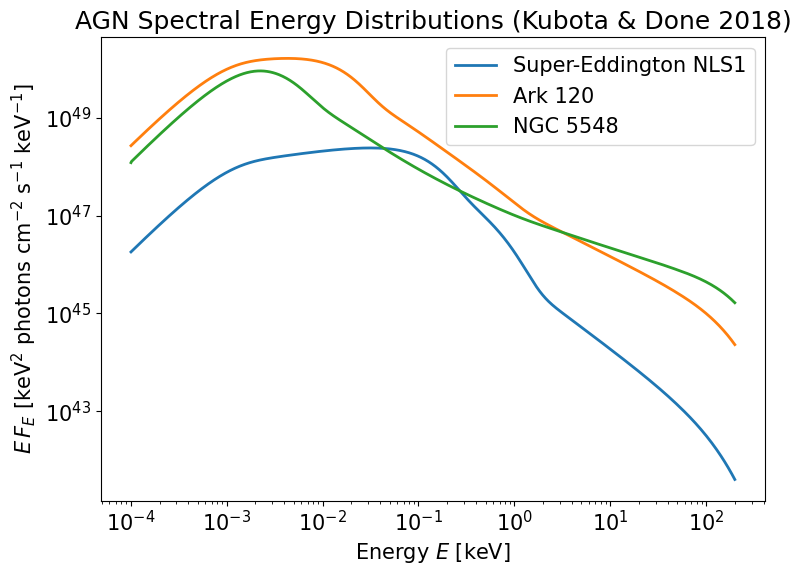

In [7]:
fig, ax = plt.subplots(figsize=(8,6))

for sed, d, label in [
    (nls1, 180, "Super-Eddington NLS1"),
    (ark120, 140, "Ark 120"),
    (ngc5548, 72, "NGC 5548")
]:

    total_flux = (
        sed.disk_flux(d)
        + sed.warm_flux(d)
        + sed.corona_flux(d)
    )

    ax.loglog(
        sed.ENERGY_RANGE_KEV,
        total_flux,
        linewidth=2,
        label=label
    )

ax.set_xlabel(r"Energy $E$ [keV]")
ax.set_ylabel(r"$E\,F_E$ [keV$^2$ photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")

ax.set_title("AGN Spectral Energy Distributions (Kubota & Done 2018)")

ax.legend()

plt.tight_layout()
plt.show()

### Main Differences Between the AGNs

Several important differences can be observed from the combined SEDs:

#### 1. UV/EUV Peak

The Super-Eddington NLS1 exhibits the strongest UV emission. Its high accretion rate ($\dot{m}=1$) produces a hotter inner accretion disk, resulting in a stronger UV/EUV peak.

Ark 120 shows a moderate UV peak, while NGC 5548 displays a broader but weaker UV emission.

#### 2. Effect of Black Hole Mass

The Super-Eddington NLS1 has the smallest black hole mass ($2\times10^6 M_\odot$), leading to a hotter accretion disk and a UV peak shifted toward higher energies.

Ark 120 possesses the largest black hole mass ($1.5\times10^8 M_\odot$), producing a cooler disk and a UV peak at lower energies.

#### 3. X-ray Emission

Ark 120 and NGC 5548 show stronger hard X-ray components compared to the Super-Eddington NLS1.

The lower accretion rates in these systems allow a larger fraction of the accretion power to emerge in the corona, enhancing X-ray emission.

#### 4. Overall Luminosity

The Super-Eddington NLS1 is dominated by thermal disk emission, whereas Ark 120 and NGC 5548 display a more balanced contribution from both disk and coronal components.

## Part (c): Parameter Exploration

The tutorial suggests exploring how the AGN SED changes with:

1. Black hole spin
2. Black hole mass
3. Accretion rate

Observations:

- Increasing spin shifts the UV/EUV peak to higher energies because the ISCO moves closer to the black hole.
- Increasing black hole mass produces a cooler accretion disk and shifts the peak to lower energies.
- Increasing the accretion rate increases the overall luminosity and strengthens the UV emission.

These trends are consistent with standard accretion disk theory and the QSOSED model.